In [1]:
import numpy as np
from bokeh.palettes import Category20
import matplotlib.pyplot as plt 
import matplotlib 
import scipy
import demes 
import demesdraw
import string
import pandas
import dpluspy
from matplotlib.transforms import ScaledTranslation

In [ ]:
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
matplotlib.rcParams['axes.linewidth'] = 0.5
lw = 0.8

: 

In [ ]:
# load required stuff from files

graph0 = "../models/human_neanderthal/main/fitted_models/null_Bherer_fit_10.yaml"
graph1 = "../models/human_neanderthal/main/fitted_models/pulses_Bherer_fit_4.yaml"
data = dpluspy.inference.load_stats(
    "../models/data/stats_Bherer_weighted.pkl", graph=graph1, return_dict=1)
bins = data["bins"]
pop_ids = data["pop_ids"]
model0 = dpluspy.inference.compute_bin_stats(graph0, bins=bins, u=1.3e-8, 
    sampled_demes=pop_ids)
model1 = dpluspy.inference.compute_bin_stats(graph1, bins=bins, u=1.3e-8, 
    sampled_demes=pop_ids)

tbl0b = pandas.read_csv("../models/human_neanderthal/bootstrap_full/null_model_Bherer.csv")
tbl1b = pandas.read_csv("../models/human_neanderthal/bootstrap_full/HN_Bherer.csv")
tbl2b = pandas.read_csv("../models/human_neanderthal/bootstrap_full/HN_HWN_Bherer.csv")
tbl0z = pandas.read_csv("../models/human_neanderthal/bootstrap_full/null_model_ZhouJHS.csv")
tbl1z = pandas.read_csv("../models/human_neanderthal/bootstrap_full/HN_ZhouJHS.csv")
tbl2z = pandas.read_csv("../models/human_neanderthal/bootstrap_full/HN_HWN_ZhouJHS.csv")

d1v0b = 2 * (np.array(tbl1b["ll"]) - np.array(tbl0b["ll"]))
d2v1b = 2 * (np.array(tbl2b["ll"]) - np.array(tbl1b["ll"]))
d2v0b = 2 * (np.array(tbl2b["ll"]) - np.array(tbl0b["ll"]))
d1v0z = 2 * (np.array(tbl1z["ll"]) - np.array(tbl0z["ll"]))
d2v1z = 2 * (np.array(tbl2z["ll"]) - np.array(tbl1z["ll"]))

: 

In [86]:
positions = {
    "Yoruba1": 1e4,
    "Stuttgart": 9e4,
    "Loschbour": 9e4,
    "UstIshim": 3e4,
    "Vindija": 1.2e5,
    "Chagyrskaya": 1.5e5, 
    "Altai": 1.8e5,
    "Denisova": 2.1e5,
    "Sup": 2.4e5,
    "MH": 5.5e4, 
    "WN": 1.35e5,
    "N": 1.55e5,
    "ND": 1.81e5,
    "Anc": 1.2e5
}
cs = Category20[20]
colors = {
    "Yoruba1": cs[0],
    "UstIshim": cs[2],
    "Loschbour": cs[4],
    "Stuttgart": cs[6],
    "Vindija": cs[8],
    "Chagyrskaya": cs[10],
    "Altai": cs[12],
    "Denisova": cs[14],
    "Sup": cs[1],
    "MH": cs[3],
    "WN": cs[5],
    "N": cs[7],
    "ND": cs[9],
    "Anc": cs[11],
}

In [87]:
def plot_graph(ax):
    fname = "../models/human_neanderthal/main/fitted_models/pulses_Bherer_fit_4.yaml"
    graph = demes.load(fname)
    pops = [
        "Yoruba1",
        "Loschbour",
        "Vindija",
        "Chagyrskaya", 
        "Altai",
        "Denisova",
        "MH", 
        "WN",
        "N",
        "ND",
        "Anc"
    ]
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        log_time=True,
        inf_ratio=0.035,
        positions={x: positions[x] for x in pops},
        colours={x: colors[x] for x in pops},
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    # annotations
    ax.annotate("Vindija", (positions["Vindija"] - 1.4e4, 3.7e4), fontsize="x-small")
    ax.annotate("Chagyrskaya", (positions["Chagyrskaya"] - 2.3e4, 4.6e4), fontsize="x-small")
    ax.annotate("Altai", (positions["Altai"] - 1e4, 9.5e4), fontsize="x-small")
    ax.annotate("Denisova", (positions["Denisova"] - 2e4, 5e4), fontsize="x-small")
    ax.annotate("Loschbour", (positions["Loschbour"] - 2e4, 6.7e3), fontsize="x-small")
    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"], fontsize="x-small")

    ax.set_xlim(-1e4, 2.28e5)
    ax.set_ylim(4e3,)
    ax.set_ylabel("Time (years)")
    return

In [88]:
lw = 1

def plot_lrt_distr1(ax):
    thresh = scipy.stats.chi2.ppf(0.95, 2)
    bins = np.concat([[0, thresh], np.linspace(thresh, 450, 40)[1:]])
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(d1v0b, bins=bins)[0] / len(d1v0b)), [0])),
            lw=lw, color="blue", label="Bhérer")
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(d1v0z, bins=bins)[0] / len(d1v0z)), [0])),
            lw=lw, color="red", label="Zhou JHS")
    # ax.hist(d1v0b, histtype="step", bins=bins, lw=lw, color="green")
    # ax.hist(d1v0z, histtype="step", bins=bins, lw=lw, color="red")
    ax.set_xlabel("LRT statistic")
    ax.set_ylabel("Frequency")
    ax.set_ylim(0, )
    ax.legend(framealpha=0, title=r"$H_0: \varnothing, H_1: \beta$", 
              title_fontsize="small")
    ax.vlines(thresh, 0, 1, color="black", lw=0.7, linestyle="--",
        transform=ax.get_xaxis_transform())
    return


def plot_lrt_distr2(ax):
    thresh = scipy.stats.chi2.ppf(0.95, 2)
    bins = np.concat([[0, thresh], np.linspace(thresh, 400, 40)[1:]])
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(d2v1b, bins=bins)[0] / len(d2v1b)), [0])),
            lw=lw, color="blue", label="Bhérer")
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(d2v1z, bins=bins)[0] / len(d2v1z)), [0])),
            lw=lw, color="red", label="Zhou JHS")
    # ax.plot([], [], lw=lw, label="Bhérer", color="blue")
    # ax.plot([], [], lw=lw, label="Zhou JHS", color="red")
    ax.set_xlabel("LRT statistic")
    ax.set_ylabel("Frequency")
    ax.legend(framealpha=0, title=r"$H_0: \beta, H_1: \beta\gamma$", 
              title_fontsize="small")
    ax.set_ylim(0, )
    ax.vlines(thresh, 0, 1, color="black", lw=0.7, linestyle="--",
        transform=ax.get_xaxis_transform())
    return

In [89]:
lw = 1


def plot_panel_d(ax):
    dpluspy.plotting.plot_data_on_ax(ax, data, "D+_1_1", "data", 
        color="grey", linestyle="--", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model0, bins, "D+_1_1",
        "null", color="tab:blue", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model1, bins, "D+_1_1",
        r"$\alpha \beta$", color="tab:orange", lw=lw)
    ax.set_title("$D^+$(Vin)", )
    ax.legend(framealpha=0)
    return


def plot_panel_e(ax):
    dpluspy.plotting.plot_data_on_ax(ax, data, "D+_1_2", "data", 
        color="grey", linestyle="--", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model0, bins, "D+_1_2",
        "null", color="tab:blue", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model1, bins, "D+_1_2",
        r"$\alpha \beta$", color="tab:orange", lw=lw)
    ax.set_title("$D^+$(Vin,Cha)")
    ax.legend(framealpha=0)
    return


def plot_panel_f(ax):
    dpluspy.plotting.plot_data_on_ax(ax, data, "D+_4_4", "data", 
        color="grey", linestyle="--", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model0, bins, "D+_4_4",
        "null", color="tab:blue", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model1, bins, "D+_4_4",
        r"$\alpha \beta$", color="tab:orange", lw=lw)
    ax.set_title("$D^+$(Los)")
    ax.legend(framealpha=0)
    return


def plot_panel_g(ax):
    dpluspy.plotting.plot_data_on_ax(ax, data, "D+_4_5", "data", 
        color="grey", linestyle="--", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model0, bins, "D+_4_5",
        "null", color="tab:blue", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model1, bins, "D+_4_5",
        r"$\alpha \beta$", color="tab:orange", lw=lw)
    ax.set_title("$D^+$(Los,Yor)")
    ax.legend(framealpha=0)
    return


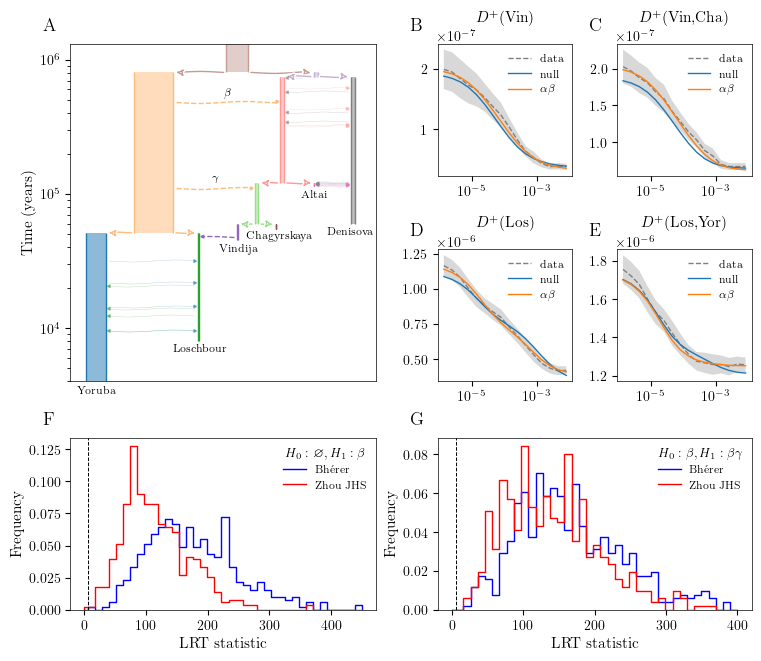

In [90]:
# mosaic = "AAA;BDE;CFG"
mosaic = "AAAABBCC;AAAADDEE;FFFFGGGG"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 6.5), layout="constrained",
                              height_ratios=[1, 1, 1.3])
for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))

plot_graph(axs["A"])
axs["A"].annotate(r"$\beta$", [1.1e5, 5.35e5], size="x-small")
axs["A"].annotate(r"$\gamma$", [1e5, 1.25e5], size="x-small")
plot_lrt_distr1(axs["F"])
plot_lrt_distr2(axs["G"])
plot_panel_d(axs["B"])
plot_panel_e(axs["C"])
plot_panel_f(axs["D"])
plot_panel_g(axs["E"])
plt.savefig("figures/fig3.pdf")

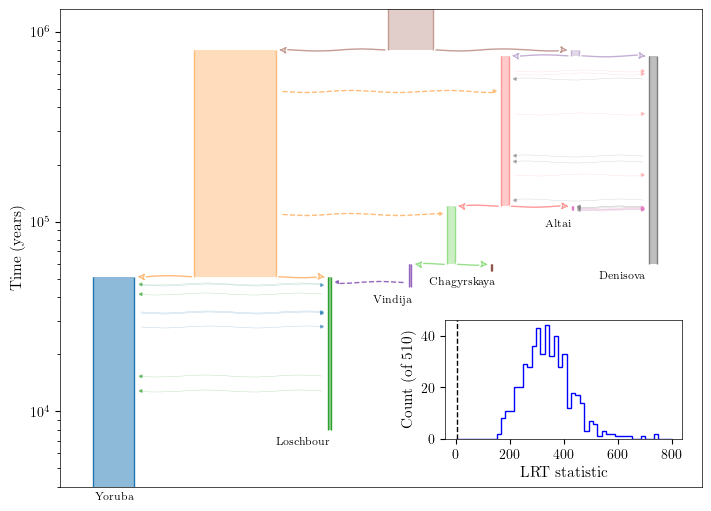

In [91]:
def _plot_graph(ax):
    fname = "../models/human_neanderthal/main/fitted_models/pulses_Bherer_fit_4.yaml"
    graph = demes.load(fname)
    sample_times = {
        "Yoruba1": 0, 
        "Loschbour": 8000, 
        "Vindija": 45000, 
        "Chagyrskaya": 55000, 
        "Altai": 115000, 
        "Denisova": 60000, 
    }
    positions = {
        "Yoruba1": -2e4,
        "Loschbour": 6e4,
        "Vindija": 9e4,
        "Chagyrskaya": 1.2e5, 
        "Altai": 1.5e5,
        "Denisova": 1.8e5,
        "MH": 2.4e4, 
        "WN": 1.05e5,
        "N": 1.3e5,
        "ND": 1.55e5,
        "Anc": 9e4
    }
    samples = [
        "Yoruba1", 
        "Loschbour", 
        "Vindija", 
        "Chagyrskaya", 
        "Altai", 
        "Denisova"
    ]
    labels = [
        "Yoruba", 
        "Loschbour", 
        "Vindija", 
        "Chagyrskaya", 
        "Altai", 
        "Denisova"
    ]
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        log_time=True,
        inf_ratio=0.035,
        positions=positions,
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    # annotations
    ax.annotate("Vindija", (positions["Vindija"] - 1e4, 3.7e4))
    ax.annotate("Chagyrskaya", (positions["Chagyrskaya"] - 1.3e4, 4.6e4))
    ax.annotate("Altai", (positions["Altai"] - 6e3, 9.3e4))
    ax.annotate("Denisova", (positions["Denisova"] - 1e4, 5e4))
    ax.annotate("Loschbour", (positions["Loschbour"] - 1.2e4, 6.5e3))
    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"])

    ax.set_ylim(4e3,)
    ax.set_ylabel("Time (years)")
    return


def plot_lrt_distr(ax):
    thresh = scipy.stats.chi2.ppf(0.95, 2)
    bins = np.concat([[0, thresh], np.linspace(thresh, 800, 50)[1:]])
    ax.hist(d2v0b, histtype="step", bins=bins, lw=lw, color="blue")
    ax.set_xlabel("LRT statistic")
    ax.set_ylabel("Count (of 510)")
    ax.vlines(thresh, 0, 1, color="black", lw=1, linestyle="--",
        transform=ax.get_xaxis_transform())
    return


fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
plot_graph(ax)
inset = ax.inset_axes([0.60, 0.10, 0.37, 0.25])
plot_lrt_distr(inset)
plt.savefig("extra_figures/hn_model.png", dpi=244)